# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bias

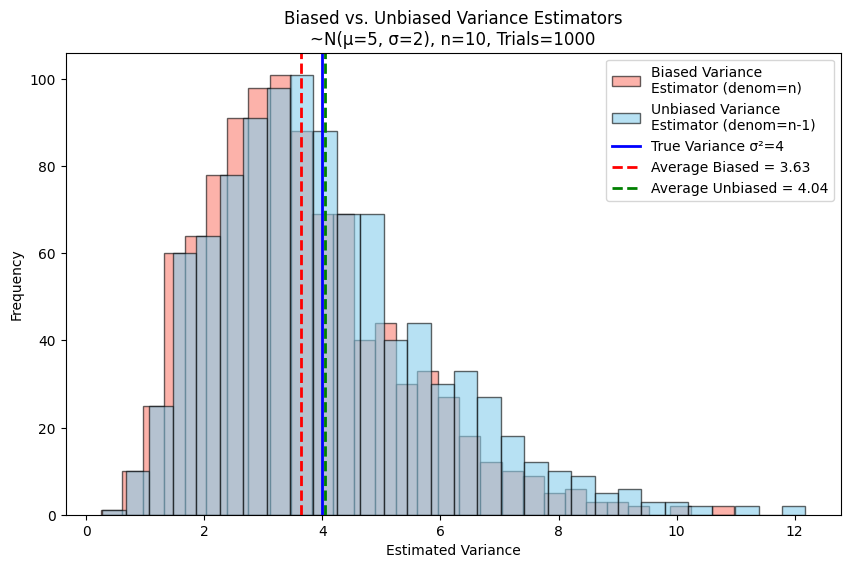

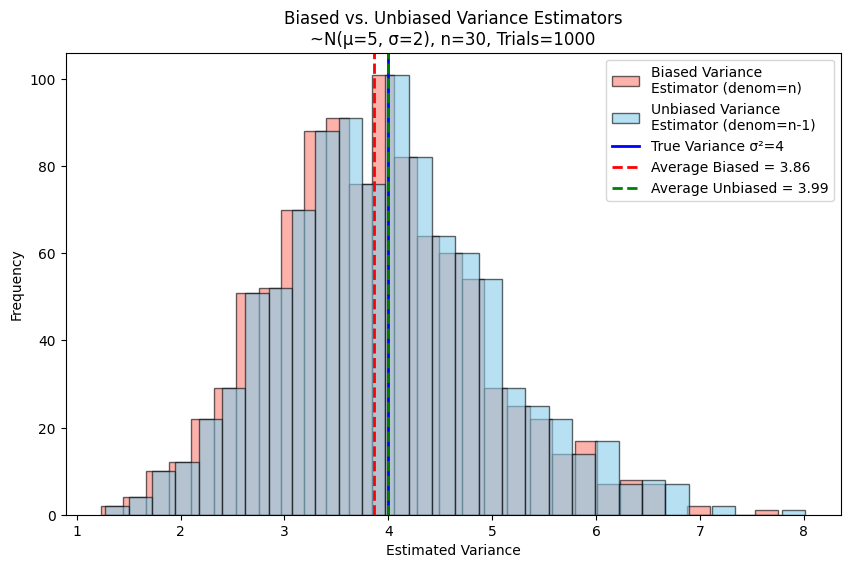

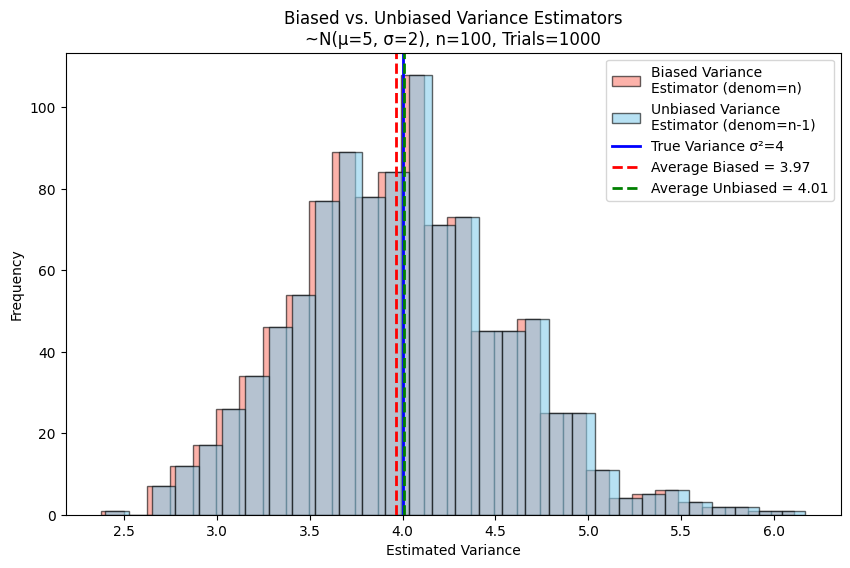

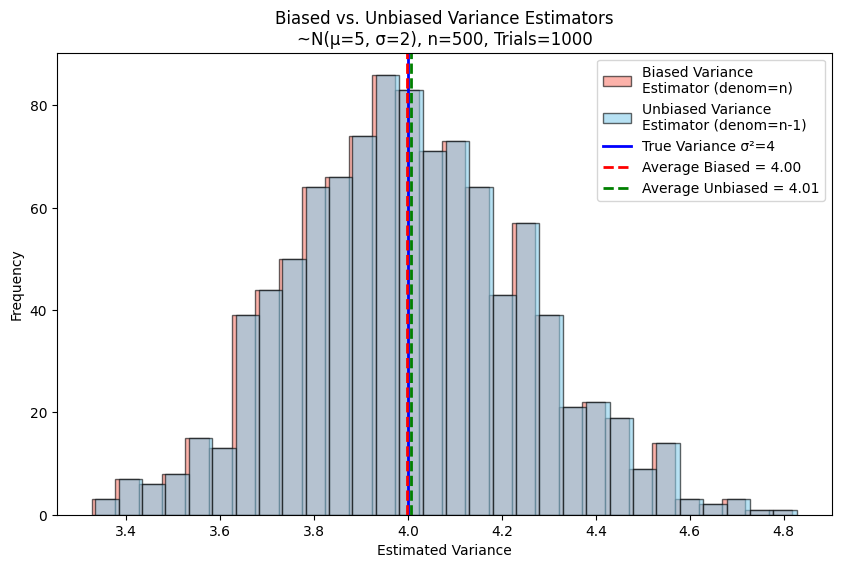

In [2]:
#  Define population 
np.random.seed(42)
mu = 5
sigma = 2   # true std
true_var = sigma**2
trials = 1000

#  List of sample sizes 
sample_sizes = [10, 30, 100, 500]

for n in sample_sizes:
    #  Store estimates 
    biased_vars = []
    unbiased_vars = []

    for _ in range(trials):
        sample = np.random.normal(mu, sigma, n)
        
        # Biased estimator: denominator n
        biased_vars.append(np.sum((sample - np.mean(sample))**2) / n)
        
        # Unbiased estimator: denominator n-1
        unbiased_vars.append(np.sum((sample - np.mean(sample))**2) / (n-1))

    #  Plot histograms 
    plt.figure(figsize=(10,6))

    # Biased variance histogram
    plt.hist(biased_vars, bins=30, alpha=0.6, color="salmon", edgecolor="black",
             label="Biased Variance\nEstimator (denom=n)")

    # Unbiased variance histogram
    plt.hist(unbiased_vars, bins=30, alpha=0.6, color="skyblue", edgecolor="black",
             label="Unbiased Variance\nEstimator (denom=n-1)")

    # True variance line
    plt.axvline(true_var, color="blue", linestyle="-", linewidth=2,
                label=f"True Variance σ²={true_var}")

    # Means of estimators
    plt.axvline(np.mean(biased_vars), color="red", linestyle="--", linewidth=2,
                label=f"Average Biased = {np.mean(biased_vars):.2f}")
    plt.axvline(np.mean(unbiased_vars), color="green", linestyle="--", linewidth=2,
                label=f"Average Unbiased = {np.mean(unbiased_vars):.2f}")

    plt.title(f"Biased vs. Unbiased Variance Estimators\n~N(μ={mu}, σ={sigma}), n={n}, Trials={trials}")

    plt.xlabel("Estimated Variance")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


# Variance

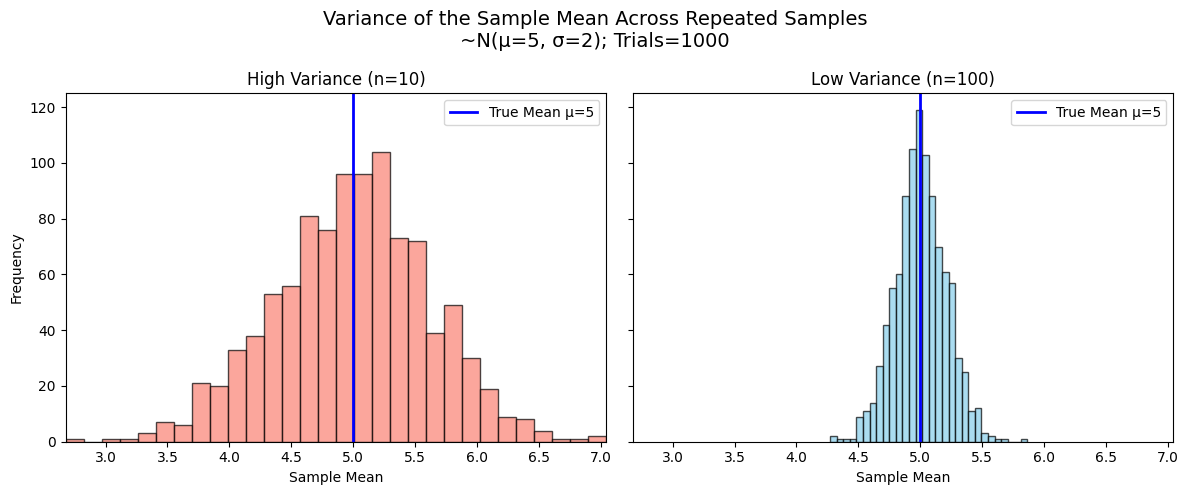

In [3]:
#  Settings 
np.random.seed(42)
mu = 5
sigma = 2
trials = 1000  # number of repeated samples

#  Case 1: High variance (small n) 
n_small = 10
means_small = [np.mean(np.random.normal(mu, sigma, n_small)) for _ in range(trials)]

#  Case 2: Low variance (large n) 
n_large = 100
means_large = [np.mean(np.random.normal(mu, sigma, n_large)) for _ in range(trials)]

#  Shared x-axis limits 
xmin = min(min(means_small), min(means_large))
xmax = max(max(means_small), max(means_large))

#  Plot side by side 
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# Histogram for small n
axes[0].hist(means_small, bins=30, color="salmon", edgecolor="black", alpha=0.7)
axes[0].axvline(mu, color="blue", linestyle="-", linewidth=2, label=f"True Mean μ={mu}")
axes[0].set_xlim(xmin, xmax)
axes[0].set_title(f"High Variance (n={n_small})")
axes[0].set_xlabel("Sample Mean")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Histogram for large n
axes[1].hist(means_large, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[1].axvline(mu, color="blue", linestyle="-", linewidth=2, label=f"True Mean μ={mu}")
axes[1].set_xlim(xmin, xmax)
axes[1].set_title(f"Low Variance (n={n_large})")
axes[1].set_xlabel("Sample Mean")
axes[1].legend()

plt.suptitle(f"Variance of the Sample Mean Across Repeated Samples\n~N(μ={mu}, σ={sigma}); Trials={trials}", fontsize=14)

plt.tight_layout()
plt.show()


# Consistency

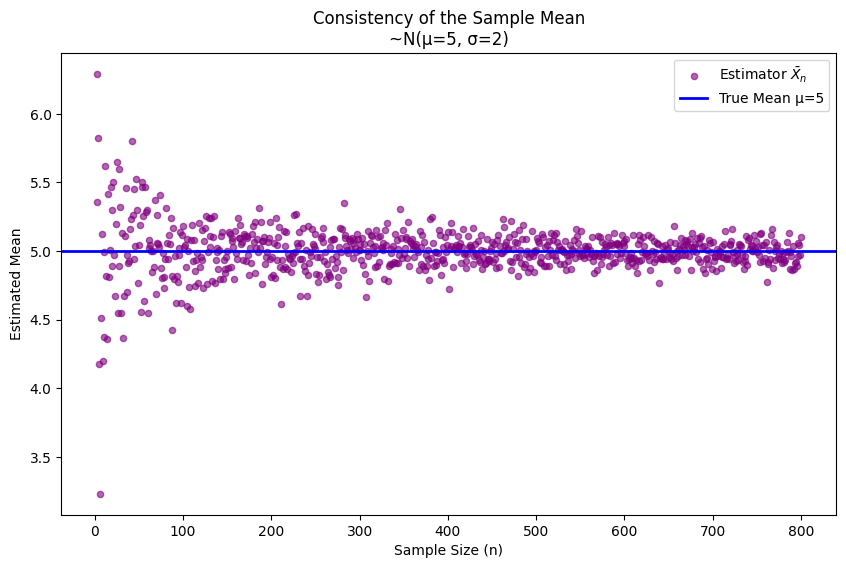

In [4]:
#  Settings 
np.random.seed(42)
mu = 5
sigma = 2
max_n = 800   # maximum sample size
trials = 1    # one estimate per n

#  Collect estimates across increasing n 
estimates = []
sample_sizes = np.arange(2, max_n+1)

for n in sample_sizes:
    est = np.mean(np.random.normal(mu, sigma, n))
    estimates.append(est)

#  Plot 
plt.figure(figsize=(10,6))
plt.scatter(sample_sizes, estimates, alpha=0.6, s=20, color="purple", label=r"Estimator $\bar{X}_n$")
plt.axhline(mu, color="blue", linestyle="-", linewidth=2, label=f"True Mean μ={mu}")

plt.title(f"Consistency of the Sample Mean\n~N(μ={mu}, σ={sigma})")

plt.xlabel("Sample Size (n)")
plt.ylabel("Estimated Mean")
plt.legend()
plt.show()


# CLT Example

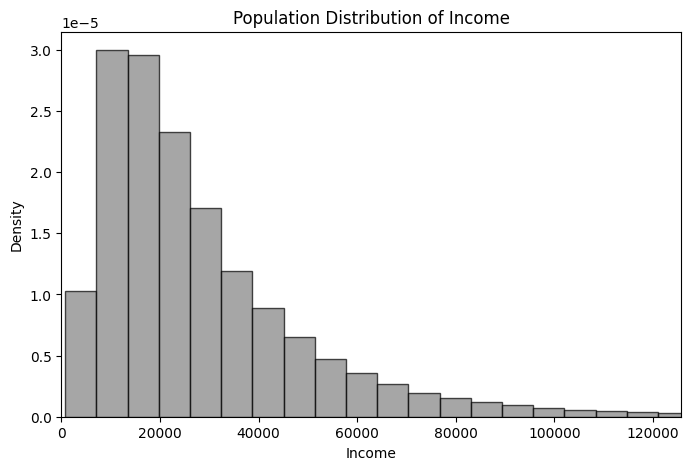

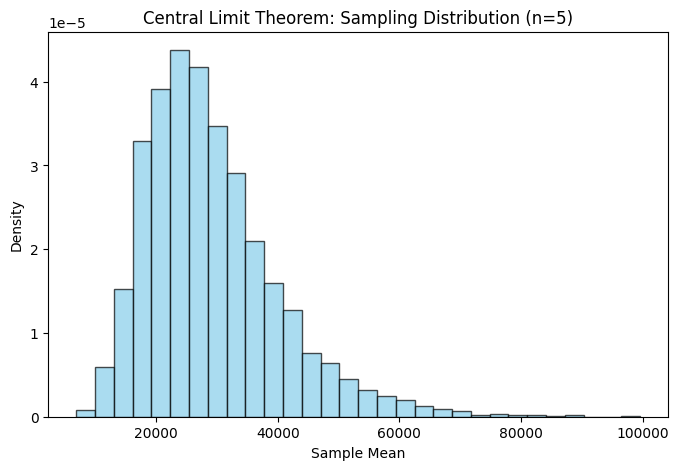

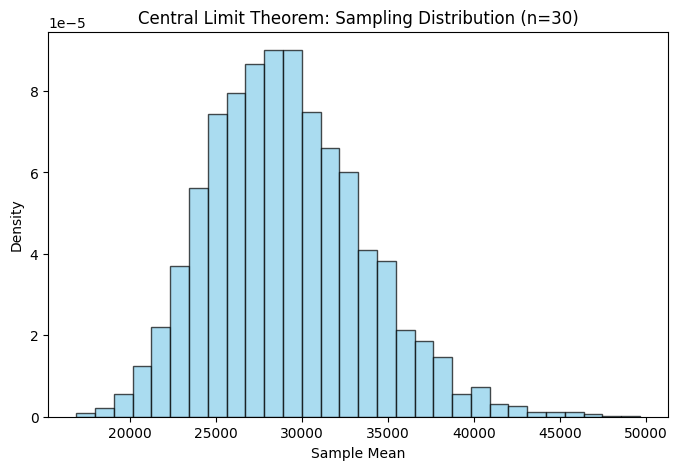

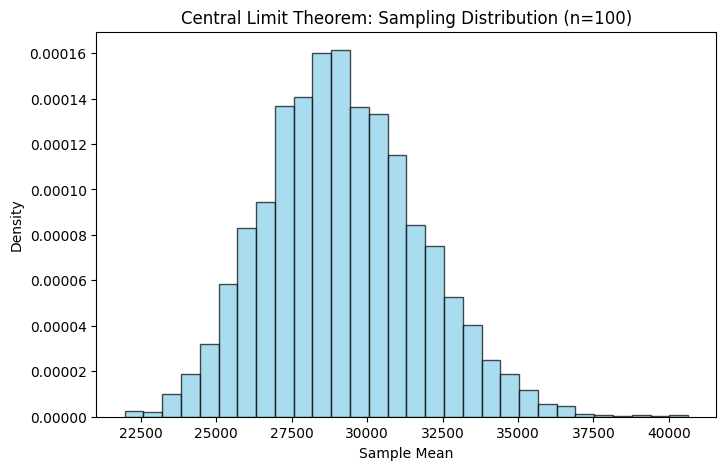

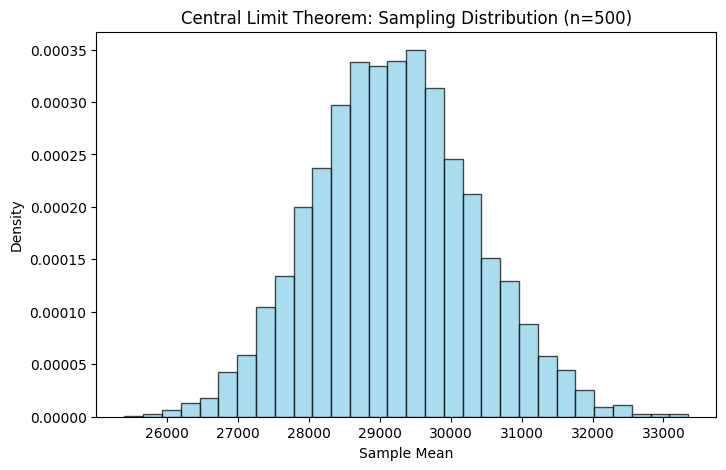

In [5]:
#  Settings 
np.random.seed(42)
trials = 5000   # number of repeated samples
mu, sigma = 10, 0.75  # lognormal parameters for income distribution

#  Generate population (income distribution) 
population = np.random.lognormal(mean=mu, sigma=sigma, size=100000)

plt.figure(figsize=(8,5))
plt.hist(population, bins=100, color="gray", edgecolor="black", alpha=0.7, density=True)
plt.title("Population Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Density")
plt.xlim(0, np.percentile(population, 99))
plt.show()

#  Sampling distributions for different n 
sample_sizes = [5, 30, 100, 500]

for n in sample_sizes:
    sample_means = [np.mean(np.random.choice(population, n, replace=True)) for _ in range(trials)]
    
    plt.figure(figsize=(8,5))
    plt.hist(sample_means, bins=30, color="skyblue", edgecolor="black", alpha=0.7, density=True)
    plt.title(f"Central Limit Theorem: Sampling Distribution (n={n})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.show()
